In [1]:
# %%
import warnings

warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#os.environ['R_HOME'] = 'D:/software/R/R-4.3.2'
#os.environ['R_USER'] = 'D:/software/anaconda/anaconda3/envs/pt20cu118/Lib/site-packages/rpy2'
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.decomposition import PCA

import STG3Net as MODEL


def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping


import anndata as ad


def get_data(config):
    count = pd.read_csv(
        "../../data/Mouse_Brain/GSE147747/GSE147747_expr_raw_counts_table.tsv",
        sep="\t", index_col=0)

    meta = pd.read_csv("../../data/Mouse_Brain/GSE147747/GSE147747_meta_table.tsv",
                       sep="\t",
                       index_col=0)

    adata_st_all = ad.AnnData(X=count.values)
    adata_st_all.obs.index = count.index
    adata_st_all.obs = meta.loc[adata_st_all.obs.index]
    adata_st_all.var.index = count.columns

    slice_use = ['01A', '02A', '03A', '04B', '05A', '06B', '07A', '08B', '09A', '10B',
                 '11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
                 '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A',
                 '31A', '32A', '33A', '34A', '35A', ]

    result, mapping = mapping2int(slice_use)

    # meta_slice = pd.read_csv(
    #     "D:\\project\\datasets\\SC_ST_Data\\snRNAseq_brain\\GSE147747\\data\\figures\\slicestable.tsv",
    #     index_col=0, sep="\t")
    # slice_AP = [float(meta_slice.loc[s]['AP']) * 1000 for s in slice_use]
    # slice_dist_micron = [-(slice_AP[i + 1] - slice_AP[i]) for i in range(len(slice_AP) - 1)]

    adata_st_all = adata_st_all[[s in slice_use for s in adata_st_all.obs.section_index.values]]
    sc.pp.filter_cells(adata_st_all, min_genes=1)

    adata_st_all.obsm['spatial'] = np.concatenate(
        (adata_st_all.obs['HE_X'].values.reshape(-1, 1), adata_st_all.obs['HE_Y'].values.reshape(-1, 1)), axis=1)

    for i, slice_id in enumerate(sorted(set(adata_st_all.obs.section_index.values))):
        adata_tmp = adata_st_all[adata_st_all.obs.section_index.values == slice_id]
        array_col = np.array([np.float32(loc.split("_")[1].split("x")[0]) for loc in adata_tmp.obs.index])
        if slice_id == '01A':
            array_col = array_col - 0.3
        array_row = np.array([np.float32(loc.split("_")[1].split("x")[1]) for loc in adata_tmp.obs.index])

        adata_tmp.obs['array_col'] = np.round(array_col)
        adata_tmp.obs['array_row'] = np.round(array_row)

        adata_tmp.obs['batch_name'] = slice_id
        adata_tmp.obs['slice_id'] = mapping[slice_id]

        adata_tmp.var_names_make_unique()
        # Remove mt-genes
        adata_tmp = adata_tmp[:, (np.array(~adata_tmp.var.index.str.startswith("mt-"))
                                  & np.array(~adata_tmp.var.index.str.startswith("MT-")))]
        adata_tmp.obs.index = adata_tmp.obs.index + "-slice%d" % i

        adata_tmp = adata_tmp[~pd.isnull(adata_tmp.obs['ABA_parent'])]

        graph_dict_tmp = MODEL.graph_construction(adata_tmp, config['k_cutoff'])
        if i == 0:
            adata = adata_tmp
            graph_dict = graph_dict_tmp
            name = slice_id
            adata.obs['proj_name'] = slice_id
        else:
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names]
            adata_tmp = adata_tmp[:, var_names]
            adata_tmp.obs['proj_name'] = slice_id

            adata = adata.concatenate(adata_tmp)
            graph_dict = MODEL.combine_graph_dict(graph_dict, graph_dict_tmp)
            name = name + '_' + slice_id
    adata.layers['count'] = adata.X
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['top_genes'])
    adata = adata[:, adata.var['highly_variable'] == True]
    sc.pp.scale(adata)

    adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
    adata.obsm['X_pca'] = adata_X
    return adata, graph_dict


import harmonypy as hm


# %%
def compute_fscoreLISI(Tmp_adata, LT_key, BT_key, PD_key):
    LISI_batch_norm = hm.compute_lisi(Tmp_adata.obsm[LT_key], Tmp_adata.obs[[BT_key]], label_colnames=[BT_key])[:, 0]
    LISI_domain_norm = hm.compute_lisi(Tmp_adata.obsm[LT_key], Tmp_adata.obs[[PD_key]], label_colnames=[PD_key])[:, 0]

    LISI = 2 * (1 / LISI_domain_norm) * LISI_batch_norm / (1 / LISI_domain_norm + LISI_batch_norm)
    return LISI


In [2]:
with open('Config/Config_MB.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [ ]:
adata, graph_dict = get_data(config['data'])

In [ ]:
num_cluster = 15
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = MODEL.G3net(adata, graph_dict=graph_dict, device=device, config=config, num_cluster=num_cluster)

In [ ]:
net.train(early_stop_epochs=100, random_seed=666)

In [ ]:
enc_rep, recon = net.process()
enc_rep = enc_rep.data.cpu().numpy()
recon = recon.data.cpu().numpy()
adata.obsm['latent'] = enc_rep
print(adata)

In [ ]:
adata = net.clustering(adata, num_cluster=num_cluster, used_obsm='latent', key_added_pred='kmeans', method='kmeans', random_seed=666)

In [ ]:
slice_use = ['01A', '02A', '03A', '04B', '05A', '06B', '07A', '08B', '09A', '10B',
                 '11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
                 '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A',
                 '31A', '32A', '33A', '34A', '35A', ]

In [ ]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from sklearn.decomposition import PCA

In [29]:
sub_adata = adata[~pd.isnull(adata.obs['ABA_parent'])]
ARI = ari_score(sub_adata.obs['ABA_parent'], sub_adata.obs['kmeans'])
print(f"total ARI:{ARI}")
ARI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['kmeans'])
    print(f"{name} ARI:{ARI}")
    ARI_list.append(ARI)
print('Mean:',np.mean(ARI_list))
print('Median:',np.median(ARI_list))

total ARI:0.36174694201561414
01A ARI:0.6162960623153119
02A ARI:0.3764224210883925
03A ARI:0.1587150528667372
04B ARI:0.21714056110413932
05A ARI:0.29366291377733317
06B ARI:0.39241993222334604
07A ARI:0.4353334793128989
08B ARI:0.426845729764355
09A ARI:0.49566004177466155
10B ARI:0.4082398042364639
11A ARI:0.42029620933507267
12A ARI:0.37063938680554087
13B ARI:0.38876582441804636
14A ARI:0.4115304620300483
15A ARI:0.3648120126363329
16A ARI:0.3774579844886997
17A ARI:0.4292175215480954
18A ARI:0.4319573565672355
19A ARI:0.46576927379762467
20B ARI:0.493980491792347
21A ARI:0.49061224215870625
22A ARI:0.4668885857115887
23A ARI:0.47405331830959946
24A ARI:0.4328773270895964
25A ARI:0.4493799988162519
26A ARI:0.42806353783154966
27A ARI:0.4537259938924834
28A ARI:0.43984184923096503
29A ARI:0.4199085162591377
30A ARI:0.36560774980141886
31A ARI:0.3258283215592919
32A ARI:0.3091847648062684
33A ARI:0.3182198065311746
34A ARI:0.3216539719624866
35A ARI:0.36727322685390673
Mean: 0.40109

In [31]:
sub_adata = adata[~pd.isnull(adata.obs['ABA_parent'])]
NMI = nmi_score(sub_adata.obs['ABA_parent'], sub_adata.obs['kmeans'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['ABA_parent'], sub_adata.obs['kmeans'])
print(f"total AMI:{AMI}")
NMI_list = []
AMI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['kmeans'])
    AMI = ami_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['kmeans'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")
    NMI_list.append(NMI)
    AMI_list.append(AMI)
print('NMI Mean:',np.mean(NMI_list))
print('NMI Median:',np.median(NMI_list))
print('AMI Mean:',np.mean(AMI_list))
print('AMI Median:',np.median(AMI_list))

total NMI:0.5524112690778477
total AMI:0.551362497893339
01A ACC:0.56780842426039
02A ACC:0.5082382539444292
03A ACC:0.33753153835054556
04B ACC:0.3801561053027033
05A ACC:0.45890503080831097
06B ACC:0.5471481510907735
07A ACC:0.5625449019642895
08B ACC:0.5797491722109125
09A ACC:0.6023852551716093
10B ACC:0.5455656388157799
11A ACC:0.5512835683249642
12A ACC:0.5460087087212762
13B ACC:0.5816515918826092
14A ACC:0.5933957384455498
15A ACC:0.5642142897892944
16A ACC:0.568600344700313
17A ACC:0.6113231013955663
18A ACC:0.603009417831103
19A ACC:0.6172528827299153
20B ACC:0.631750830810806
21A ACC:0.6617195337007205
22A ACC:0.6352762421751318
23A ACC:0.6276696344687974
24A ACC:0.5985693612709935
25A ACC:0.5498775252060256
26A ACC:0.556212354479732
27A ACC:0.5902253104683546
28A ACC:0.5750369528769486
29A ACC:0.572070686616266
30A ACC:0.5268788372095075
31A ACC:0.5103735144395143
32A ACC:0.4804902297017577
33A ACC:0.49959292575465675
34A ACC:0.5186941057304247
35A ACC:0.5488319220607596
NM

In [32]:
sub_adata = adata[~pd.isnull(adata.obs['ABA_parent'])]
HOM = hom_score(sub_adata.obs['ABA_parent'], sub_adata.obs['kmeans'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['ABA_parent'], sub_adata.obs['kmeans'])
print(f"total COM:{COM}")
V_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['kmeans'])
    COM = com_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['kmeans'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")
    V_list.append(V)
print('V Mean:',np.mean(V_list))
print('V Median:',np.median(V_list))

total HOM:0.5931000461727464
total COM:0.5169468712105366
01A V:0.5737848066698176
02A V:0.5137600451107255
03A V:0.3516825984151802
04B V:0.3936365720041952
05A V:0.4704708541641818
06B V:0.5569450529341935
07A V:0.5708355179338971
08B V:0.5888330364681056
09A V:0.6103827804353166
10B V:0.5545127867569684
11A V:0.5617410601586146
12A V:0.5576994988264327
13B V:0.5920849879563174
14A V:0.6034890253689472
15A V:0.575449329503697
16A V:0.5797986597378927
17A V:0.620710566755002
18A V:0.613654849263524
19A V:0.6273973179995906
20B V:0.641794192213508
21A V:0.6693030060671162
22A V:0.6440443926720643
23A V:0.6368151602847073
24A V:0.6082555449208974
25A V:0.5620396970435387
26A V:0.5670951421533919
27A V:0.5985357371168758
28A V:0.5833907549562236
29A V:0.5808212198222981
30A V:0.5356262185689159
31A V:0.5181835240752749
32A V:0.4890116144090432
33A V:0.5066098752155062
34A V:0.5257286261587895
35A V:0.5576334269004332
V Mean: 0.5640502136868909
V Median: 0.5737848066698176


5.342380073319313
1.1345877475027248


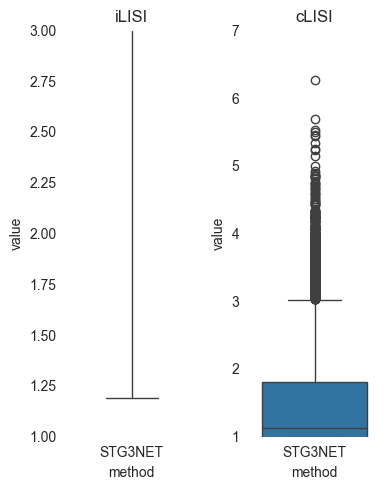

In [33]:
import seaborn as sns
import harmonypy as hm
import matplotlib.pyplot as plt

iLISI = hm.compute_lisi(adata.obsm['latent'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(adata.obsm['latent'], adata.obs[['ABA_parent']], label_colnames=['ABA_parent'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'STG3NET',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'STG3NET',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

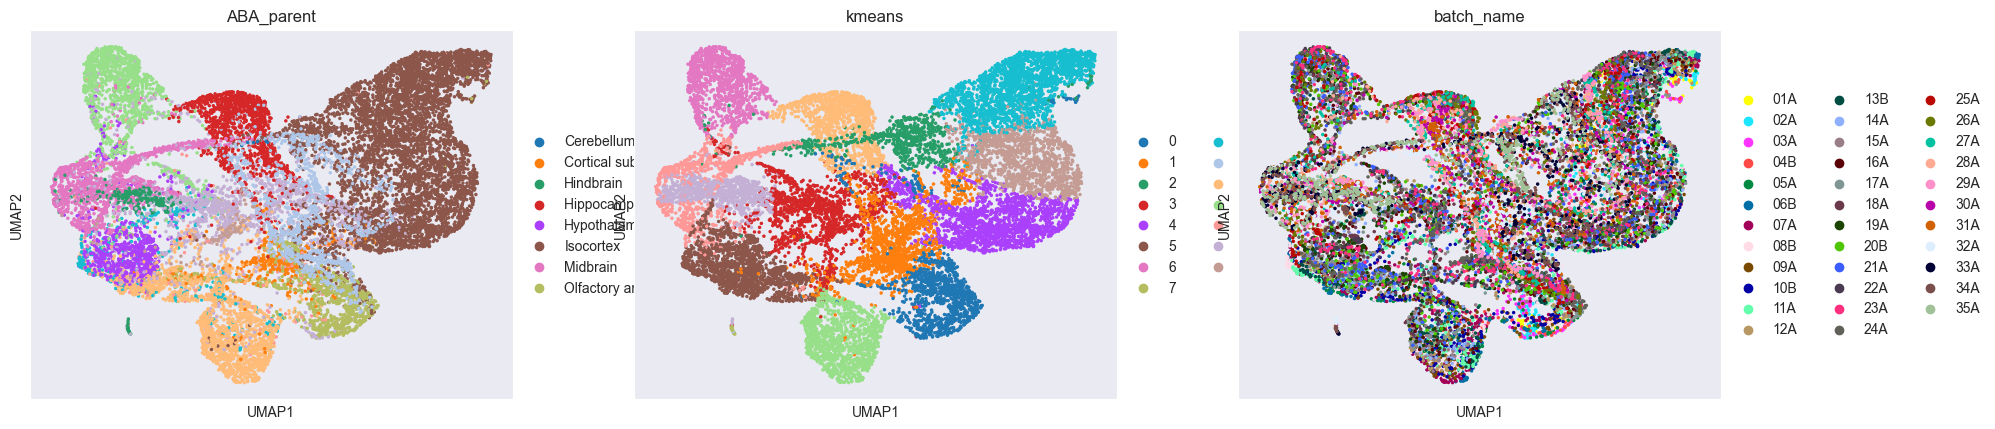

In [9]:
# %%
sc.pp.neighbors(adata, use_rep='latent', metric='cosine')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ABA_parent', 'kmeans', 'batch_name'], show=True, size=25, save=False)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
slice_use = ['01A', '02A', '03A', '04B', '05A', '06B', '07A', '08B', '09A', '10B',
             '11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
             '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A',
             '31A', '32A', '33A', '34A', '35A', ]
BT_key = 'batch_name'
GT_key = 'ABA_parent'
PD_key = 'kmeans'
LT_key = 'latent'

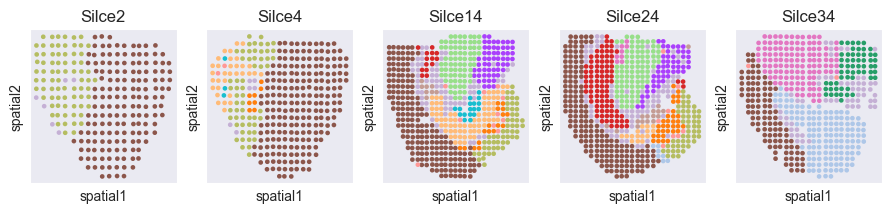

In [18]:
plt.figure(figsize=(11, 2))
k = 1
for i in [1, 3, 13, 23, 33]:
    adata_tmp = adata[adata.obs[BT_key] == slice_use[i]]
    ax = plt.subplot(1, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=GT_key, s=45, ax=ax, show=False, legend_loc=False)
    # sc.pl.embedding(adata_list[i], basis='spatial', color='spatial_domain', s=45, ax=ax, show=False)
    plt.title(f'Silce{i + 1}')
    k += 1

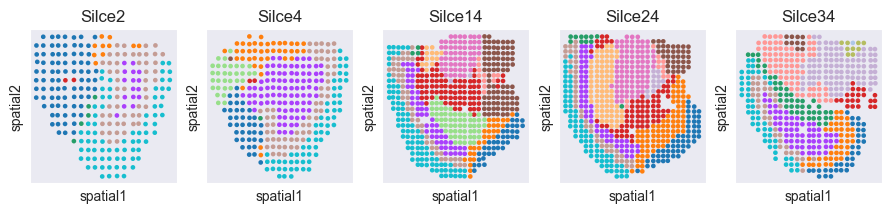

In [19]:
plt.figure(figsize=(11, 2))
k = 1
for i in [1, 3, 13, 23, 33]:
    adata_tmp = adata[adata.obs[BT_key] == slice_use[i]]
    ax = plt.subplot(1, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=45, ax=ax, show=False, legend_loc=False)
    # sc.pl.embedding(adata_list[i], basis='spatial', color='spatial_domain', s=45, ax=ax, show=False)
    plt.title(f'Silce{i + 1}')
    k += 1

In [20]:
find_slice = ['11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
              '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A', ]

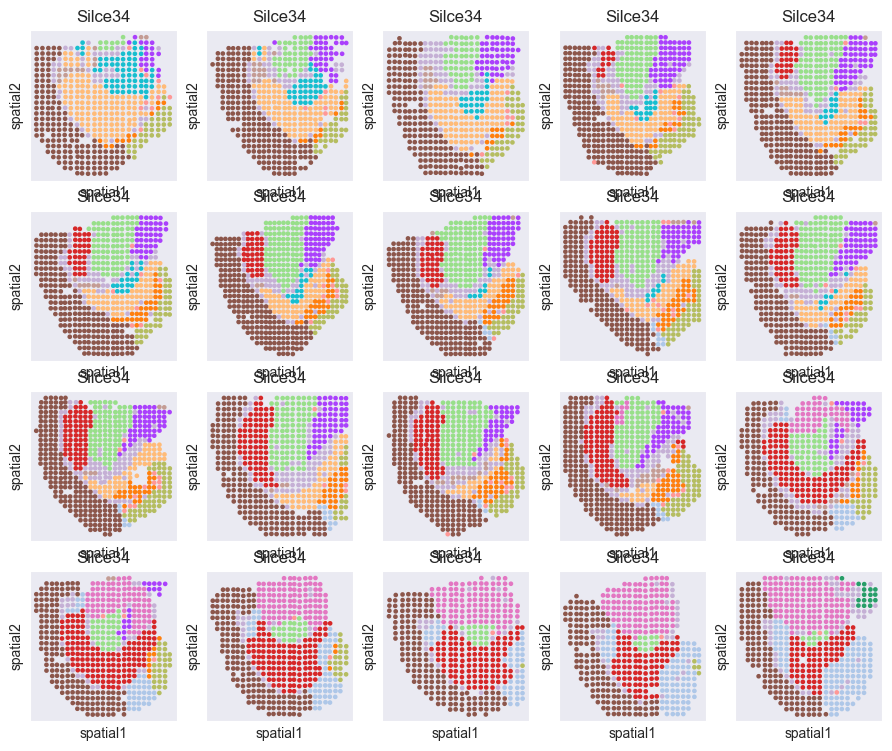

In [21]:
plt.figure(figsize=(11, 16))
k = 1
for slice_id, slice_name in enumerate(find_slice):
    adata_tmp = adata[adata.obs[BT_key] == find_slice[slice_id]]
    ax = plt.subplot(7, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=GT_key, s=45, ax=ax, show=False, legend_loc=False)
    # sc.pl.embedding(adata_list[i], basis='spatial', color='spatial_domain', s=45, ax=ax, show=False)
    plt.title(f'Silce{i + 1}')
    k += 1

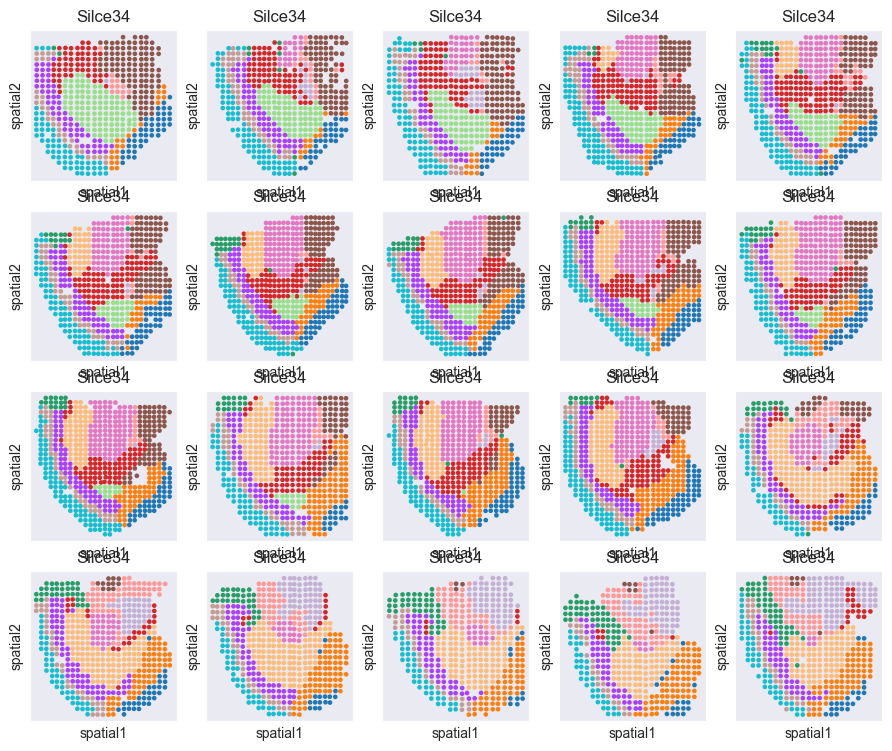

In [22]:
plt.figure(figsize=(11, 16))
k = 1
for slice_id, slice_name in enumerate(find_slice):
    adata_tmp = adata[adata.obs[BT_key] == find_slice[slice_id]]
    ax = plt.subplot(7, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=45, ax=ax, show=False, legend_loc=False)
    # sc.pl.embedding(adata_list[i], basis='spatial', color='spatial_domain', s=45, ax=ax, show=False)
    plt.title(f'Silce{i + 1}')
    k += 1

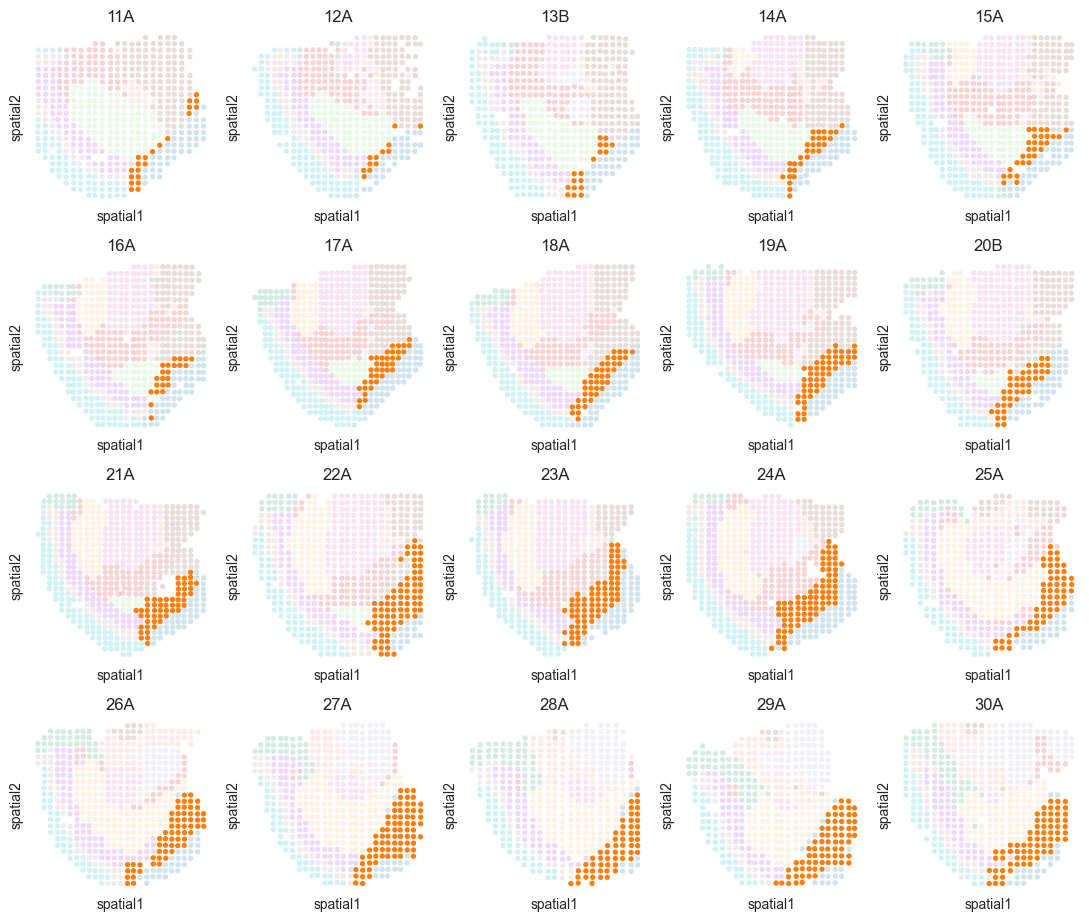

In [23]:
# sub = adata[adata.obs['mclust'] == 3]
# sc.pl.spatial(sub, spot_size=30, color='mclust', ax=axes[i], legend_loc=None, show=False)
# find_slice = slice_use
plt.rcParams['axes.facecolor'] = 'white'

target_domain = 1
sub = adata[adata.obs['kmeans'] == target_domain]
subnon = adata[adata.obs['kmeans'] != target_domain]
plt.figure(figsize=(11, 16))
k = 1
for slice_id, slice_name in enumerate(find_slice):
    adata_tmp = sub[sub.obs[BT_key] == find_slice[slice_id]]
    ax = plt.subplot(7, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=60, ax=ax, show=False, legend_loc=False,alpha=1)
    
    
    adata_tmp = subnon[subnon.obs[BT_key] == find_slice[slice_id]]
    ax = plt.subplot(7, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=60, ax=ax, show=False, legend_loc=False, alpha=0.2)
    # sc.pl.embedding(adata_list[i], basis='spatial', color='spatial_domain', s=45, ax=ax, show=False)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

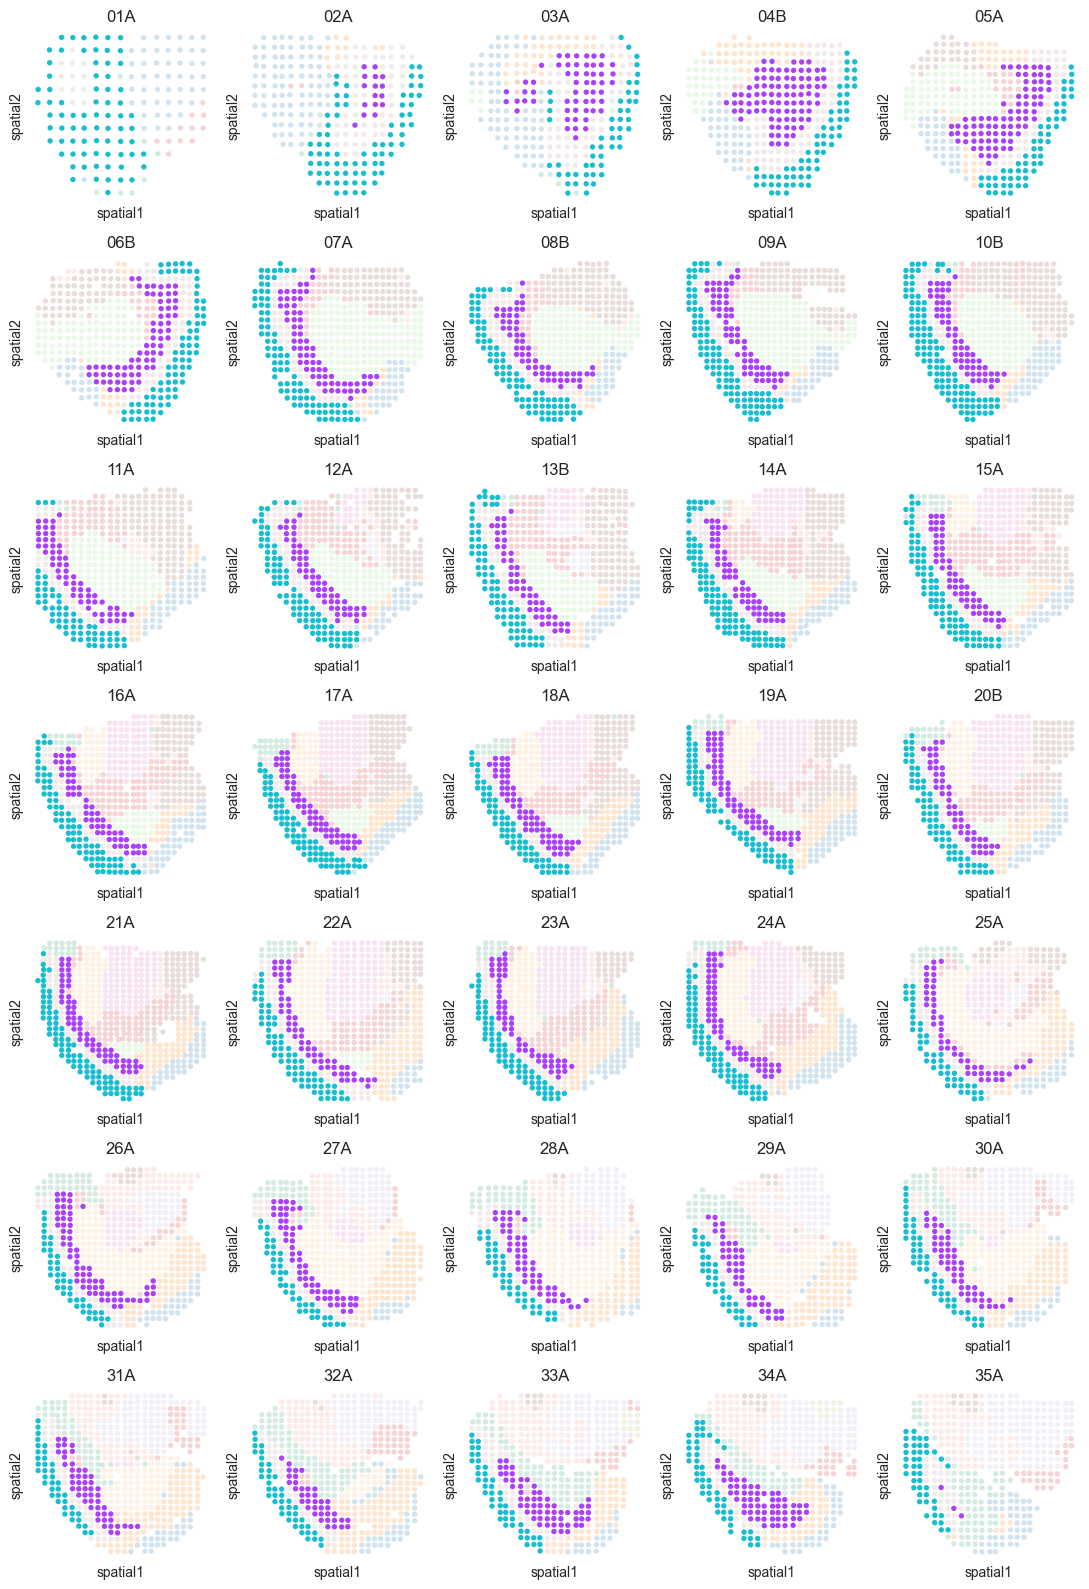

In [24]:
landmark1 = 8 
landmark2 = 4 
sub1 = adata[adata.obs['kmeans'] == landmark1 ]
sub2 = adata[adata.obs['kmeans'] == landmark2 ]
subnon = adata[adata.obs['kmeans'] != landmark1]
subnon = subnon[subnon.obs['kmeans'] != landmark2]
# sub = adata[adata.obs['mclust'] == 3]
# sc.pl.spatial(sub, spot_size=30, color='mclust', ax=axes[i], legend_loc=None, show=False)
# find_slice = slice_use
plt.figure(figsize=(11, 16))
k = 1
for slice_id, slice_name in enumerate(slice_use):
    adata_tmp = sub1[sub1.obs[BT_key] == slice_use[slice_id]]
    ax = plt.subplot(7, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=
    60, ax=ax, show=False, legend_loc=False, alpha=1)
    adata_tmp = sub2[sub2.obs[BT_key] == slice_use[slice_id]]
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=60, ax=ax, show=False, legend_loc=False, alpha=1)

    adata_tmp = subnon[subnon.obs[BT_key] == slice_use[slice_id]]
    ax = plt.subplot(7, 5, k)
    sc.pl.embedding(adata_tmp, basis='spatial', color=PD_key, s=60, ax=ax, show=False, legend_loc=False, alpha=0.2)
    # sc.pl.embedding(adata_list[i], basis='spatial', color='spatial_domain', s=45, ax=ax, show=False)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

In [34]:
adata.write('STG3Net_MOB.h5ad')